In [ ]:
%pip install numpy pandas matplotlib seaborn scipy scikit-learn kagglehub

# 0. Initializing the project files

* Import Python packages (including Google Colab)
* Load CSVs into dataframes
* `.head()` and `.info()` to view at a glance

In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import ast

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    google_path = '/content/drive/My Drive/DSE 200 - Python for Data Analysis/Mini Project/'
except:
    google_path = './'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Download latest version
path = kagglehub.dataset_download("ihormuliar/starbucks-customer-data")

print("Path to dataset files:", path)

# portfolio.csv
portfolio_df = pd.read_csv(path + "/portfolio.csv")

# profile.csv
profile_df = pd.read_csv(path + "/profile.csv")

# transcript.csv
transcript_df = pd.read_csv(path + "/transcript.csv")

Path to dataset files: /root/.cache/kagglehub/datasets/ihormuliar/starbucks-customer-data/versions/1


In [ ]:
portfolio_df.head(), profile_df.head(), transcript_df.head()

(   Unnamed: 0  reward                              channels  difficulty  \
 0           0      10         ['email', 'mobile', 'social']          10   
 1           1      10  ['web', 'email', 'mobile', 'social']          10   
 2           2       0            ['web', 'email', 'mobile']           0   
 3           3       5            ['web', 'email', 'mobile']           5   
 4           4       5                      ['web', 'email']          20   
 
    duration     offer_type                                id  
 0         7           bogo  ae264e3637204a6fb9bb56bc8210ddfd  
 1         5           bogo  4d5c57ea9a6940dd891ad53e9dbe8da0  
 2         4  informational  3f207df678b143eea3cee63160fa8bed  
 3         7           bogo  9b98b8c7a33c4b65b9aebfe6a799e6d9  
 4        10       discount  0b1e1539f2cc45b7b9fa7c272da2e1d7  ,
    Unnamed: 0 gender  age                                id  became_member_on  \
 0           0    NaN  118  68be06ca386d4c31939f3a4f0e3dd783          20170

In [ ]:
portfolio_df.info(), profile_df.info(), transcript_df.info()
# 2175 entries that have null values in gender and income

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10 non-null     int64 
 1   reward      10 non-null     int64 
 2   channels    10 non-null     object
 3   difficulty  10 non-null     int64 
 4   duration    10 non-null     int64 
 5   offer_type  10 non-null     object
 6   id          10 non-null     object
dtypes: int64(4), object(3)
memory usage: 688.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  object 
 2   age               17000 non-null  int64  
 3   id                17000 non-null  object 
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64


(None, None, None)

# 1. Cleaning Data
* `profile_df`
  * Cast `became_member_on` from string to datetime
  * Drop customers that have null `gender` and `income` and 118 year old `age`
* `transcript_df`
  * Create new column `offer_id` from `values`
  * `transcript_df.head()` to view at a glance

In [ ]:
# Adding new column from became_member_on to handle datetime functions
profile_df['became_member_on_dt'] = pd.to_datetime(profile_df['became_member_on'], format='%Y%m%d')

# Dropping genderless, incomeless, 118 year olds
profile_df = profile_df[(profile_df['age'] != 118) & (profile_df['gender'].notnull()) & (profile_df['income'].notnull())]

In [ ]:
# Extracting offer IDs from 'value' column

# converts value column from string to actual dictionary
transcript_df['value'] = transcript_df['value'].apply(lambda x: ast.literal_eval(x))

# str accessor + get('key') to get keys outside of Series
transcript_df['value'].str.get('offer id')
# offer_id also has reward, offer id doesn't have reward, amount just has amount

def extract_offer_id(value):
    if 'offer id' in value:
        return value['offer id']
    elif 'offer_id' in value:
        return value['offer_id']
    elif 'amount' in value:
        return value['amount']
    else:
        return None

transcript_df['offer_id'] = transcript_df['value'].apply(extract_offer_id)

In [ ]:
transcript_df.head()

,Unnamed: 0,person,event,value,time,offer_id
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,9b98b8c7a33c4b65b9aebfe6a799e6d9
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,0b1e1539f2cc45b7b9fa7c272da2e1d7
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,2906b810c7d4411798c6938adc9daaa5
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,fafdcd668e3743c1bb461111dcafc2a4
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,4d5c57ea9a6940dd891ad53e9dbe8da0


## 1.5 Table connections

* `offers_df` connects the three dataframes through customers that interacted to any capacity to an offer
  * This is the only dataframe used in EDA and advanced analytics
* `transactions_df` connects the regular transactions to people (and not to offers)
* `all_df` connects the three dataframes in an outer join
* All newly created dataframes exported to csv in Google Drive

In [ ]:
# creating dataframe of just offers
offers_df = pd.merge(transcript_df, profile_df, left_on='person', right_on='id')
offers_df = pd.merge(offers_df, portfolio_df, left_on='offer_id', right_on='id')
offers_df.to_csv(google_path + 'offers_df.csv', index=False)
offers_df.head()

,Unnamed: 0_x,person,event,value,time,offer_id,Unnamed: 0_y,gender,age,id_x,became_member_on,income,became_member_on_dt,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id_y
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,9b98b8c7a33c4b65b9aebfe6a799e6d9,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0,2017-05-09,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
1,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,2906b810c7d4411798c6938adc9daaa5,5,M,68,e2127556f4f64592b11af22de27a7932,20180426,70000.0,2018-04-26,9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5
2,5,389bc3fa690240e798340f5a15918d5c,offer received,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},0,f19421c1d4aa40978ebb69ca19b0e20d,8,M,65,389bc3fa690240e798340f5a15918d5c,20180209,53000.0,2018-02-09,8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
3,7,2eeac8d8feae4a8cad5a6af0499a211d,offer received,{'offer id': '3f207df678b143eea3cee63160fa8bed'},0,3f207df678b143eea3cee63160fa8bed,12,M,58,2eeac8d8feae4a8cad5a6af0499a211d,20171111,51000.0,2017-11-11,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
4,8,aa4862eba776480b8bb9c68455b8c2e1,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,0b1e1539f2cc45b7b9fa7c272da2e1d7,13,F,61,aa4862eba776480b8bb9c68455b8c2e1,20170911,57000.0,2017-09-11,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [ ]:
offers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148805 entries, 0 to 148804
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Unnamed: 0_x         148805 non-null  int64         
 1   person               148805 non-null  object        
 2   event                148805 non-null  object        
 3   value                148805 non-null  object        
 4   time                 148805 non-null  int64         
 5   offer_id             148805 non-null  object        
 6   Unnamed: 0_y         148805 non-null  int64         
 7   gender               148805 non-null  object        
 8   age                  148805 non-null  int64         
 9   id_x                 148805 non-null  object        
 10  became_member_on     148805 non-null  int64         
 11  income               148805 non-null  float64       
 12  became_member_on_dt  148805 non-null  datetime64[ns]
 13  Unnamed: 0    

In [ ]:
# creating dataframe of just transactions
transactions_df = pd.merge(transcript_df, profile_df, left_on='person', right_on='id')
transactions_df = transactions_df[transactions_df['event'] == 'transaction']
transactions_df.to_csv(google_path + 'transactions_df.csv', index=False)
transactions_df.head()

,Unnamed: 0_x,person,event,value,time,offer_id,Unnamed: 0_y,gender,age,id,became_member_on,income,became_member_on_dt
11027,12654,02c083884c7d45b39cc68e1314fec56c,transaction,{'amount': 0.8300000000000001},0,0.83,41,F,20,02c083884c7d45b39cc68e1314fec56c,20160711,30000.0,2016-07-11
11030,12657,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,transaction,{'amount': 34.56},0,34.56,55,M,42,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,20160117,96000.0,2016-01-17
11032,12659,54890f68699049c2a04d415abc25e717,transaction,{'amount': 13.23},0,13.23,63,M,36,54890f68699049c2a04d415abc25e717,20171228,56000.0,2017-12-28
11040,12670,b2f1cd155b864803ad8334cdf13c4bd2,transaction,{'amount': 19.51},0,19.51,134,F,55,b2f1cd155b864803ad8334cdf13c4bd2,20171016,94000.0,2017-10-16
11041,12671,fe97aa22dd3e48c8b143116a8403dd52,transaction,{'amount': 18.97},0,18.97,151,F,39,fe97aa22dd3e48c8b143116a8403dd52,20171217,67000.0,2017-12-17


In [ ]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 123957 entries, 11027 to 272761
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Unnamed: 0_x         123957 non-null  int64         
 1   person               123957 non-null  object        
 2   event                123957 non-null  object        
 3   value                123957 non-null  object        
 4   time                 123957 non-null  int64         
 5   offer_id             123957 non-null  object        
 6   Unnamed: 0_y         123957 non-null  int64         
 7   gender               123957 non-null  object        
 8   age                  123957 non-null  int64         
 9   id                   123957 non-null  object        
 10  became_member_on     123957 non-null  int64         
 11  income               123957 non-null  float64       
 12  became_member_on_dt  123957 non-null  datetime64[ns]
dtypes: datetime64[n

In [ ]:
all_df = pd.merge(transcript_df, profile_df, left_on='person', right_on='id')
all_df = pd.merge(all_df, portfolio_df, left_on='offer_id', right_on='id', how='outer')
all_df.to_csv(google_path + 'all_df.csv', index=False)
all_df.head()

,Unnamed: 0_x,person,event,value,time,offer_id,Unnamed: 0_y,gender,age,id_x,became_member_on,income,became_member_on_dt,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id_y
0,12967,db691240326b44d8bfa7b438c4c41982,transaction,{'amount': 0.05},0,0.05,1898,M,46,db691240326b44d8bfa7b438c4c41982,20161205,46000.0,2016-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15057,cf6c877f4d7d411aa0e3bb4a7a566834,transaction,{'amount': 0.05},0,0.05,14319,M,31,cf6c877f4d7d411aa0e3bb4a7a566834,20180516,36000.0,2018-05-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,18839,2c810363d6e2458f82bf4c9030661aa6,transaction,{'amount': 0.05},12,0.05,6012,M,79,2c810363d6e2458f82bf4c9030661aa6,20180316,32000.0,2018-03-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20329,c2c72ce6038644c797208046d1e3498a,transaction,{'amount': 0.05},18,0.05,454,F,49,c2c72ce6038644c797208046d1e3498a,20171016,57000.0,2017-10-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22234,093f0c09cc7242228edbb0e52ca14af6,transaction,{'amount': 0.05},18,0.05,16454,M,36,093f0c09cc7242228edbb0e52ca14af6,20170617,35000.0,2017-06-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272762 entries, 0 to 272761
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Unnamed: 0_x         272762 non-null  int64         
 1   person               272762 non-null  object        
 2   event                272762 non-null  object        
 3   value                272762 non-null  object        
 4   time                 272762 non-null  int64         
 5   offer_id             272762 non-null  object        
 6   Unnamed: 0_y         272762 non-null  int64         
 7   gender               272762 non-null  object        
 8   age                  272762 non-null  int64         
 9   id_x                 272762 non-null  object        
 10  became_member_on     272762 non-null  int64         
 11  income               272762 non-null  float64       
 12  became_member_on_dt  272762 non-null  datetime64[ns]
 13  Unnamed: 0    

# 2. Exploratory Data Analysis

*Offer Performance Analysis* - Which types of offers are most successful?

*Customer Segmentation* - Can we identify distinct customer groups based on their response to offers?

*Channel Effectiveness* - Which communication channels are most effective for different customer segments?

*Customer Behavior Patterns* - How does membership tenure relate to offer response?

In [ ]:
# Picking the next 3 colors in matplotlib's default property cycle
color_cycle = plt.cm.tab10.colors
event_colors = color_cycle[:3]          # received=blue, viewed=orange, completed=green
offer_type_colors = color_cycle[3:6]    # bogo=red, discount=purple, informational=brown

## 1. Which types of offers are most successful?
#### 1.5 Between bogo and discount, which one has higher total difficulty?

Success is measured both by **count of offer types** and by the **difficulty** associated with the offer types.

* **Discount** offers account for higher `count` and higher amount measured by `difficulty` more than **bogo**.
* **Informational** doesn't have any immediately profitable value measured by `difficulty`

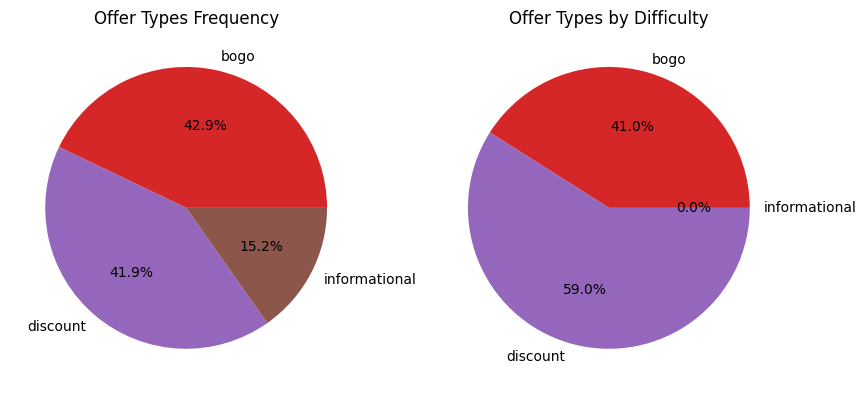

In [ ]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.pie(offers_df['offer_type'].value_counts(), labels=offers_df['offer_type'].value_counts().index, autopct='%1.1f%%', colors=offer_type_colors)
plt.title('Offer Types Frequency')

plt.subplot(1, 2, 2)
plt.pie(offers_df.groupby('offer_type')['difficulty'].sum(), labels=offers_df.groupby('offer_type')['difficulty'].sum().index, autopct='%1.1f%%', colors=offer_type_colors)
plt.title('Offer Types by Difficulty')

plt.show()

## 2. Can we identify distinct customer groups based on their response to offers?

* More offers pushed to **men** than women but both genders yield similar count of offer completion.
* Age distribution peaks around **50-60 year olds**
* Income highest around **50-70k**
* Membership date
  * Summer 2013-Summer 2015 low offers
  * Summer 2015-Summer 2017 more offers, same received/completion ratio as previous time period
  * Summer 2017-early 2018 very large offers campaign, but smaller ratio of offers received/completed
  * early 2018-Summer 2018 scaled back offers campaign, keeping similar offers received/completed ratio as previous time period

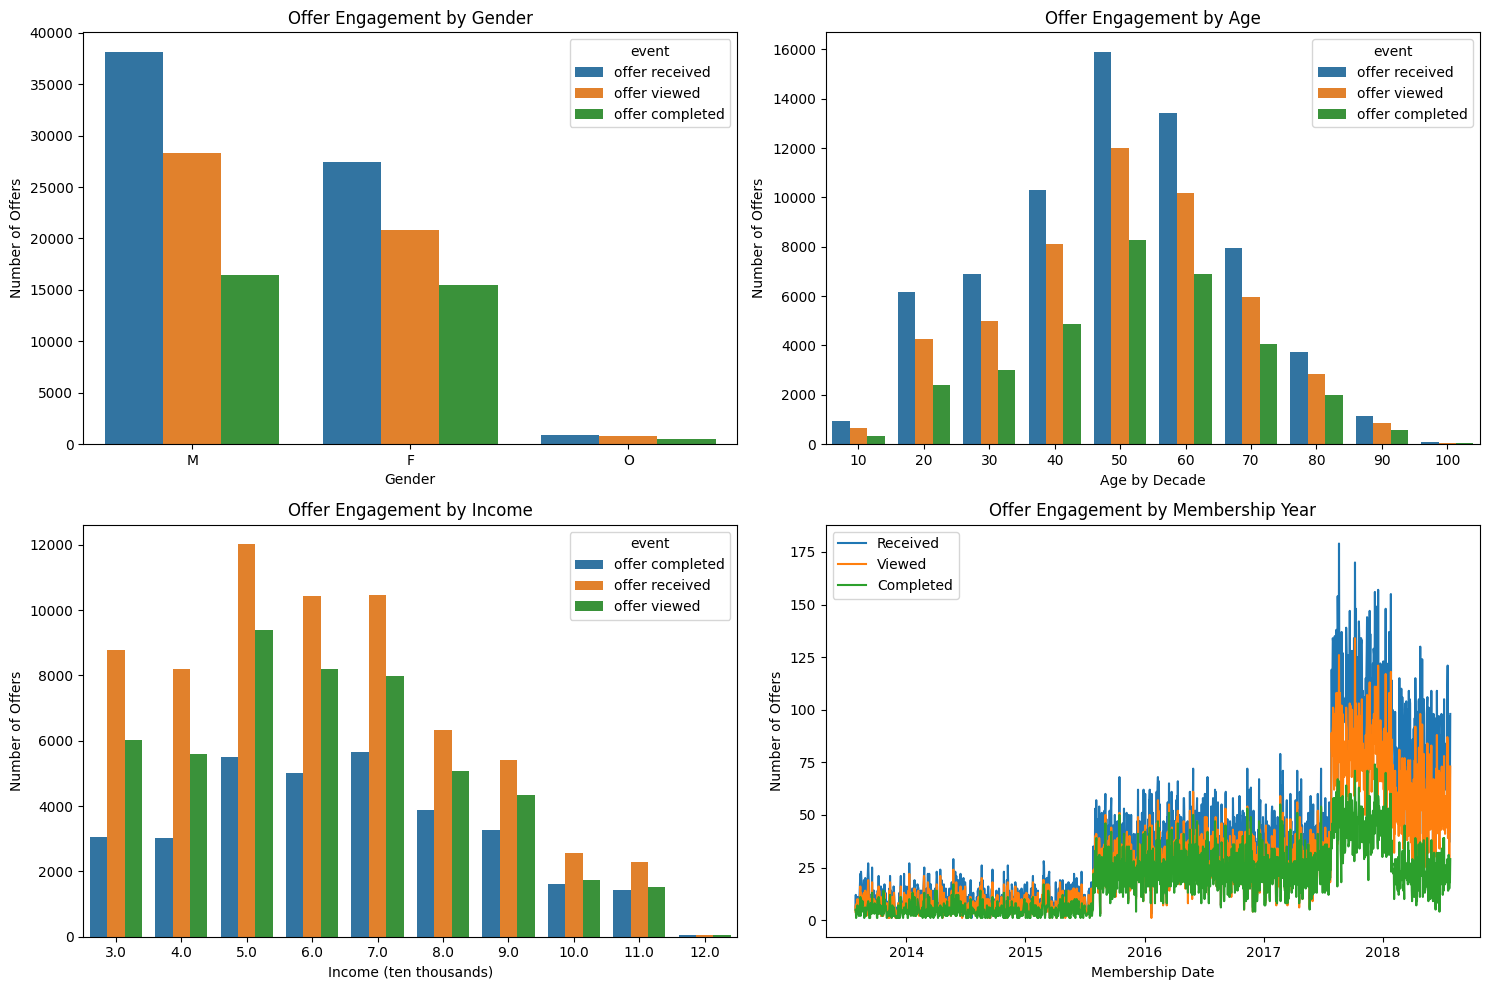

In [ ]:
plt.figure(figsize=(15, 10))
event_order = ['offer received', 'offer viewed', 'offer completed']

plt.subplot(2, 2, 1)
gender_order = ['M', 'F', 'O']
gender_offer = offers_df.groupby(['gender', 'event'])['event'].count().reset_index(name='count')
sns.barplot(x='gender', y='count', data=gender_offer, hue='event', hue_order=event_order, order=gender_order)
plt.xlabel('Gender')
plt.ylabel('Number of Offers')
plt.title('Offer Engagement by Gender')

plt.subplot(2, 2, 2)
offers_df['age_decade'] = offers_df['age'].apply(lambda x: (x // 10) * 10)
age_offer = offers_df.groupby(['age_decade', 'event'])['event'].count().reset_index(name='count')
sns.barplot(x='age_decade', y='count', hue='event', data=age_offer, hue_order=event_order)
plt.xlabel('Age by Decade')
plt.ylabel('Number of Offers')
plt.title('Offer Engagement by Age')

plt.subplot(2, 2, 3)
offers_df['income_tenthousands'] = offers_df['income'].apply(lambda x: x // 10000)
income_offer = offers_df.groupby(['income_tenthousands', 'event'])['event'].count().reset_index(name='count')
sns.barplot(x='income_tenthousands', y='count', hue='event', data=income_offer)
plt.xlabel('Income (ten thousands)')
plt.ylabel('Number of Offers')
plt.title('Offer Engagement by Income')

plt.subplot(2, 2, 4)
# Quiet in 2013-June 2015, then from June 2015-June 2017 more offers
# Then last half of 2017 bumped up offers, but the ratio of received to completed is worse, so 2018 fewer received
plt.plot(offers_df[offers_df['event'] == 'offer received'].groupby('became_member_on_dt')['event'].count(), label='Received')
plt.plot(offers_df[offers_df['event'] == 'offer viewed'].groupby('became_member_on_dt')['event'].count(), label='Viewed')
plt.plot(offers_df[offers_df['event'] == 'offer completed'].groupby('became_member_on_dt')['event'].count(), label='Completed')

plt.legend()
plt.xlabel('Membership Date')
plt.ylabel('Number of Offers')
plt.title('Offer Engagement by Membership Year')

plt.tight_layout()
plt.show()


## 4. How does membership tenure relate to offer response?

**Offers are given and completed to newer members** than older members, implying there are many "new member" rewards.

Offers stop being completed past a certain membership tenure even though they're still being given out to some older members.

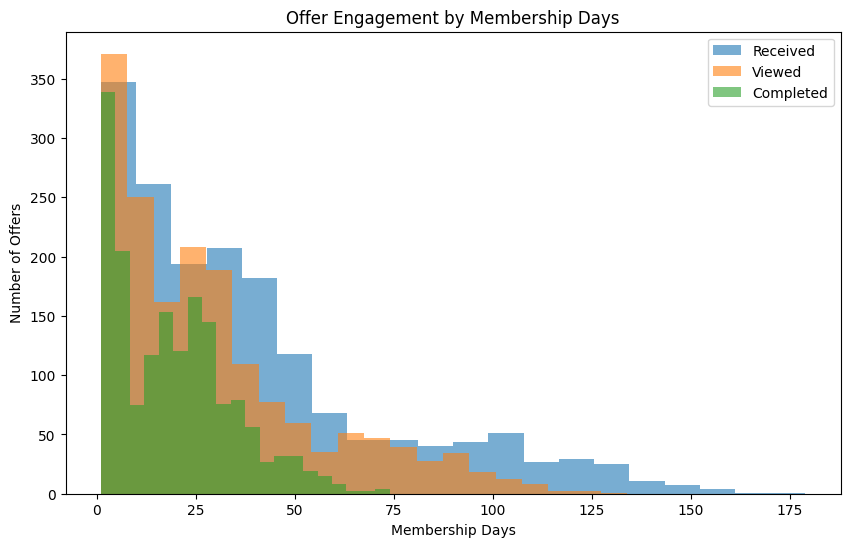

In [ ]:
import datetime
plt.figure(figsize=(10, 6))

offers_df['became_member_on_dt'] = pd.to_datetime(offers_df['became_member_on_dt'], unit='D', origin='unix')
offers_df['membership_days'] = (pd.Timestamp.today().normalize() - offers_df['became_member_on_dt']).dt.days


plt.hist(offers_df[offers_df['event'] == 'offer received'].groupby('membership_days')['event'].count(), bins=20, alpha=0.6, label='Received')
plt.hist(offers_df[offers_df['event'] == 'offer viewed'].groupby('membership_days')['event'].count(), bins=20, alpha=0.6, label='Viewed')
plt.hist(offers_df[offers_df['event'] == 'offer completed'].groupby('membership_days')['event'].count(), bins=20, alpha=0.6, label='Completed')

plt.legend()
plt.xlabel('Membership Days')
plt.ylabel('Number of Offers')
plt.title('Offer Engagement by Membership Days')
plt.show()

## 3. Does multi-channel marketing improve offer success?

**Yes.** Across `offer type` and `event` measures, the channel with the most values in the list consistently have more offers being pushed and completed.

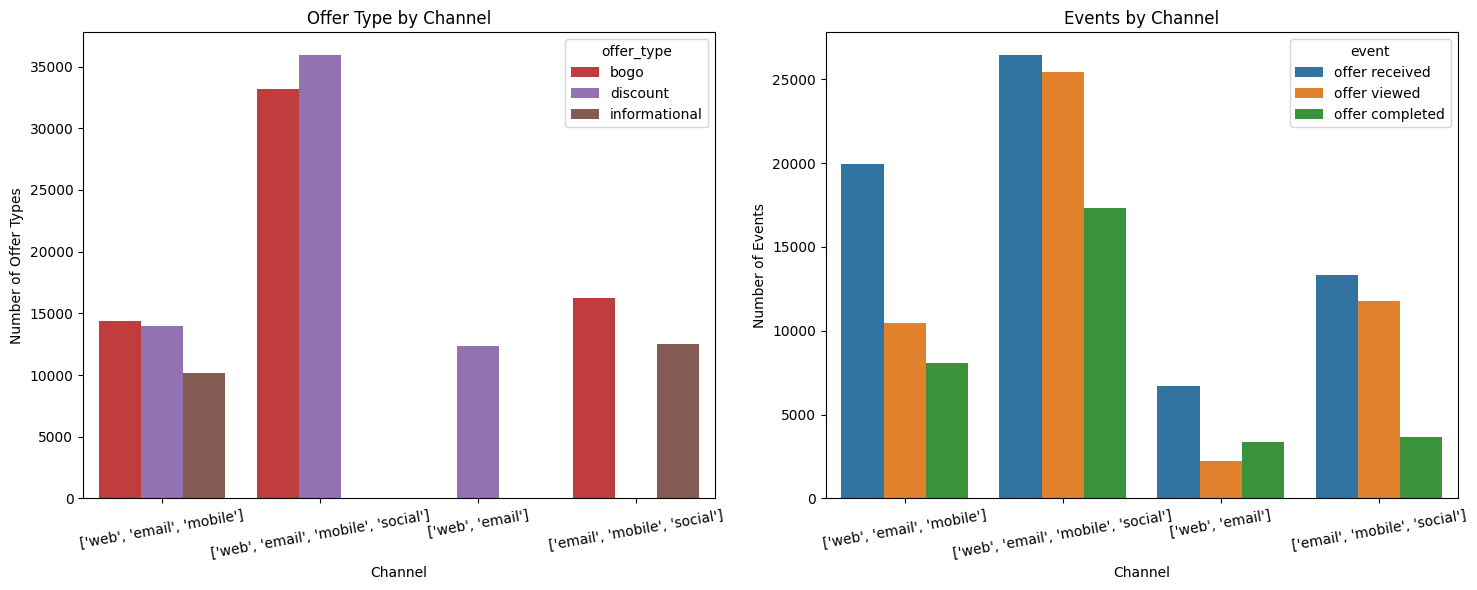

In [ ]:
# 3. Does multi-channel marketing improve offer success?
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='channels', data=offers_df, hue='offer_type', dodge=True, palette=offer_type_colors)
plt.xlabel('Channel')
plt.xticks(rotation=10)
plt.ylabel('Number of Offer Types')
plt.title('Offer Type by Channel')

plt.subplot(1, 2, 2)
sns.countplot(x='channels', data=offers_df, hue='event', dodge=True)
plt.xlabel('Channel')
plt.xticks(rotation=10)
plt.ylabel('Number of Events')
plt.title('Events by Channel')

plt.tight_layout()
plt.show()

# 3. Advanced Analytics

* Preprocess to convert categorical data to numerical data (`LabelEncoder`)
  * Further handling of other numeric columns for modeling requirements
* `.head()` and `.info()` to view at a glance
* Heatmap of new numeric data columns
* Customer Segmentation using K-Means
* Offer Success Prediction using Linear Regression


## Preprocessing for advanced analytics
* Import analytics packages
* Use `LabelEncoder` to change categorical data to numerical data
* `.head()` and `.info()` to view at a glance
* Heatmap of new numeric data columns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# label encoding for offers_df
from sklearn.preprocessing import LabelEncoder
event_le = LabelEncoder()
gender_le = LabelEncoder()
offer_type_le = LabelEncoder()
channels_le = LabelEncoder()


offers_df['event'] = event_le.fit_transform(offers_df['event'])       # offer received, viewed, completed OR transaction
offers_df['gender'] = gender_le.fit_transform(offers_df['gender'])     # M, F, O
offers_df['offer_type'] = offer_type_le.fit_transform(offers_df['offer_type'])   # bogo, discount, informational
offers_df['channels'] = channels_le.fit_transform(offers_df['channels'])      # web, email, mobile, social
offers_df['membership_days'] = offers_df['membership_days'] - 2297      # scales the membership_days away from epoch
offers_df['became_member_on_dt'] = pd.to_datetime(offers_df['became_member_on_dt'])
offers_df['became_member_on_dt'] = offers_df['became_member_on_dt'].astype('int64') // 10**9 // 86400

offers_df.head()

,Unnamed: 0_x,person,event,value,time,offer_id,Unnamed: 0_y,gender,age,id_x,...,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id_y,age_decade,income_tenthousands,membership_days
0,0,78afa995795e4d85b5d9ceeca43f5fef,1,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,9b98b8c7a33c4b65b9aebfe6a799e6d9,3,0,75,78afa995795e4d85b5d9ceeca43f5fef,...,3,5,2,5,7,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,70,10.0,443
1,2,e2127556f4f64592b11af22de27a7932,1,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,2906b810c7d4411798c6938adc9daaa5,5,1,68,e2127556f4f64592b11af22de27a7932,...,9,2,2,10,7,1,2906b810c7d4411798c6938adc9daaa5,60,7.0,91
2,5,389bc3fa690240e798340f5a15918d5c,1,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},0,f19421c1d4aa40978ebb69ca19b0e20d,8,1,65,389bc3fa690240e798340f5a15918d5c,...,8,5,1,5,5,0,f19421c1d4aa40978ebb69ca19b0e20d,60,5.0,167
3,7,2eeac8d8feae4a8cad5a6af0499a211d,1,{'offer id': '3f207df678b143eea3cee63160fa8bed'},0,3f207df678b143eea3cee63160fa8bed,12,1,58,2eeac8d8feae4a8cad5a6af0499a211d,...,2,0,2,0,4,2,3f207df678b143eea3cee63160fa8bed,50,5.0,257
4,8,aa4862eba776480b8bb9c68455b8c2e1,1,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,0b1e1539f2cc45b7b9fa7c272da2e1d7,13,0,61,aa4862eba776480b8bb9c68455b8c2e1,...,4,5,3,20,10,1,0b1e1539f2cc45b7b9fa7c272da2e1d7,60,5.0,318


In [ ]:
offers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148805 entries, 0 to 148804
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0_x         148805 non-null  int64  
 1   person               148805 non-null  object 
 2   event                148805 non-null  int64  
 3   value                148805 non-null  object 
 4   time                 148805 non-null  int64  
 5   offer_id             148805 non-null  object 
 6   Unnamed: 0_y         148805 non-null  int64  
 7   gender               148805 non-null  int64  
 8   age                  148805 non-null  int64  
 9   id_x                 148805 non-null  object 
 10  became_member_on     148805 non-null  int64  
 11  income               148805 non-null  float64
 12  became_member_on_dt  148805 non-null  int64  
 13  Unnamed: 0           148805 non-null  int64  
 14  reward               148805 non-null  int64  
 15  channels         

<Axes: >

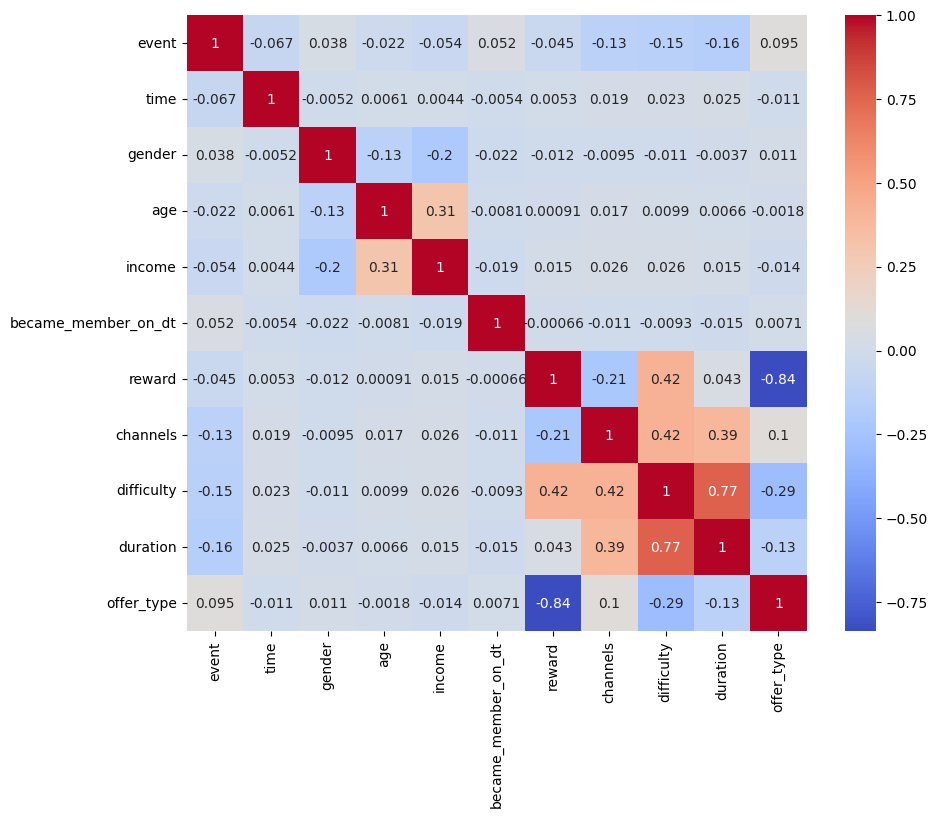

In [ ]:
numerical_features = offers_df.select_dtypes(include=['number']).columns
numerical_features = numerical_features.drop(['Unnamed: 0_x', 'Unnamed: 0_y', 'Unnamed: 0', 'age_decade', 'income_tenthousands'])

heatmap_data = numerical_features.drop(['membership_days', 'became_member_on'])   # this is just to clean up the heatmap by 1 less column
numerical_df = offers_df[heatmap_data]

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), cmap='coolwarm', annot=True)

## Declare features for Clustering and Linear Regression
* `age`
* `membership_days`
* `income`
* `channels`
* `difficulty`
* `reward`

In [ ]:
features = ['age', 'membership_days', 'income', 'channels', 'difficulty', 'reward']

## K-Means for Customer Clustering

* Use elbow method to find ideal k value
* Print all categorical data that was passed through a `LabelEncoder` regardless of whether it was used in `features`
  * For flexibility and transparency in case `features` changes
* Produced **8 customer demographics**
  * Mid 50s, member for over a year, around 65k income
  * Early 60s, member for almost 2 years, around 90k income
  * Early 50s, member for over 3 years, almost 60k income
  * Mid 30s, member for almost a year, low 50k income
  * Late 60s, member for almost a year, around 55k income
  * Mid 50s, member for almost 2 years, income around 67k
  * Mid 60s, member for almost 2 years, income around 80k
  * Early 40s, member for a year and a half, income around 50k

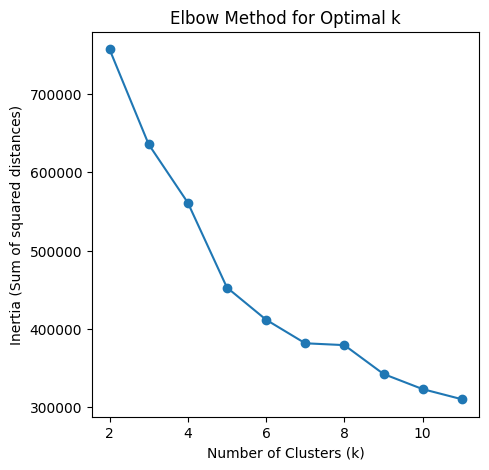

Gender: ['F' 'M' 'O']
Events: ['offer completed' 'offer received' 'offer viewed']
Offer Types: ['bogo' 'discount' 'informational']
Channels: ["['email', 'mobile', 'social']" "['web', 'email', 'mobile', 'social']"
 "['web', 'email', 'mobile']" "['web', 'email']"]
         age  membership_days        income  channels  difficulty     reward
0  54.309618       462.549953  65028.085610  0.000000    0.000000   0.000000
1  62.780766       514.158868  91874.317735  1.431155    6.607561   2.991376
2  51.289982      1254.999611  58668.591737  1.316526    6.672035   3.394602
3  35.780569       332.496932  53001.070796  1.407561    6.569540   2.987974
4  67.527857       325.975723  55516.841080  1.423760    6.504724   2.995509
5  55.429058       540.061248  67819.583029  3.000000   20.000000   5.000000
6  65.338169       537.026332  81688.528587  0.506278   10.000000  10.000000
7  43.194596       446.556900  51030.785777  0.478053   10.000000  10.000000


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Preprocess and norrmalize data
X = offers_df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(offers_df[features])

# Elbow method to find k
k_range = range(2, 12)
inertia = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)  # Fit the model to the scaled data
    inertia.append(kmeans.inertia_)  # Store the inertia

plt.figure(figsize=(5, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.show()


# Apply K-Means clustering
ideal_k = 8  # Based on the elbow method
kmeans = KMeans(n_clusters=ideal_k, random_state=42)
kmeans.fit(X_scaled)  # Fit the model to the data

# Get the centroids and labels
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

print('Gender:', gender_le.classes_)
print('Events:',event_le.classes_)
print('Offer Types:',offer_type_le.classes_)
print('Channels:', channels_le.classes_)
print(offers_df.groupby(labels)[features].mean())

# Visualize the clusters and centroids
# plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
# plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X')  # Mark centroids
# plt.title("K-Means Clustering with 4 Clusters")
# plt.show()


## Offer Success Prediction
* Features: `age`, `membership tenure`, `income`, `channels`, `difficulty`, `reward`
* **Linear Regression Model**
* The model needs to be refined with better features to predict offer success.
* MSE: 0.1370
* R^2: 0.7260
* **Random Forest Model**
* This model needs to be refined with better features to predict offer success.
* MSE: 0.0
* R^2: 1.0

In [ ]:
# Linear Regression Model
# Define features and targets
X = offers_df[features]
y = offers_df['offer_type']

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Declare and train model
lr = LinearRegression()
lr.fit(X_train,y_train)

# Make predictions on test set
y_pred = lr.predict(X_test)
print(features)
print('Linear Regression MSE:', mean_squared_error(y_test, y_pred))
print('Linear Regression R^2:', lr.score(X_test,y_test))

['age', 'membership_days', 'income', 'channels', 'difficulty', 'reward']
Linear Regression MSE: 0.13694711135297588
Linear Regression R^2: 0.726036132502582


In [ ]:
# Random Forest Regression Model
# Declare and train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Make predictions on test set
y_pred = rf.predict(X_test)
y_train_pred = rf.predict(X_train)
print('Random Forest MSE:', mean_squared_error(y_test, y_pred))   # 0.0
print('Random Forest R^2:', rf.score(X_test,y_test))              # 1.0
print('Random Forest Train MSE:', mean_squared_error(y_train, y_train_pred))
print('Random Forest Train R^2:', rf.score(X_train,y_train_pred))


Random Forest MSE: 0.0
Random Forest R^2: 1.0
Random Forest Train MSE: 0.0
Random Forest Train R^2: 1.0
